# Data complexity effects on synthetic data quality

## Step 4: Analyze paper figures

This notebook loads saved evaluation results, prepares the paper analysis tables, and produces the figures used in the paper.

## Setup

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
from torch import manual_seed
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
EXP = "syndaite"
PROJECT_DIR = Path.cwd().resolve()

INPUT_DIR = PROJECT_DIR / "data" / "synth_input" / EXP
OUTPUT_DIR = PROJECT_DIR / "data" / "synth_output" / EXP
RESULT_DIR = PROJECT_DIR / "results" / EXP
FIG_DIR = PROJECT_DIR / "results" / "figs" / EXP

RANDOM_SEEDS = [42]
SAVE_FIGS = True
if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
plt.rcParams["savefig.dpi"] = 300

np.random.seed(RANDOM_SEEDS[0])
manual_seed(RANDOM_SEEDS[0])
random.seed(RANDOM_SEEDS[0])

In [4]:
def project_path(path):
    path = Path(path)
    return path if path.is_absolute() else PROJECT_DIR / path


def get_feature_cols(df, target_col):
    return [c for c in df.columns if c != target_col]

## Load Data

In [5]:
manifest = pd.read_csv(INPUT_DIR / f"{EXP}_manifest.csv")
synthetic_manifest = pd.read_csv(OUTPUT_DIR / f"{EXP}_synthetic_manifest.csv")

In [6]:
MODELS = ["CART", "TVAE"]

base_utility = pd.read_csv(RESULT_DIR / f"{EXP}_base_utility.csv")
eval_res = pd.read_csv(RESULT_DIR / f"{EXP}_eval_results.csv")
input_complex_df = pd.read_csv(RESULT_DIR / f"{EXP}_input_complex.csv")
ratios = pd.read_csv(RESULT_DIR / f"{EXP}_ratios.csv").rename(columns={"Diff": "IR_Diff"})

## Prepare Analysis Tables

In [7]:
metrics = eval_res.groupby("EvalType")["Property"].unique().to_dict()
qual_metrics = np.concatenate([
    metrics["pymdma"],
    metrics["sdv_diag"],
    metrics["sdv_qual"],
]).tolist()

input_complex_long = input_complex_df.melt(
    id_vars=["Dataset"],
    var_name="Property",
    value_name="Score",
)
input_complex_long["EvalType"] = "input_complexity"

manifest_param_cols = [
    col for col in manifest.columns
    if col not in ["base_path", "full_path", "train_path", "test_path", "metadata_path", "target_col"]
]
params_long = manifest[manifest_param_cols].melt(
    id_vars=["Dataset"],
    var_name="Property",
    value_name="Score",
)
params_long["EvalType"] = "dataset_param"

input_data_df = pd.concat([input_complex_long, params_long], ignore_index=True)
input_data_wide = pd.pivot_table(
    input_data_df,
    index="Dataset",
    columns="Property",
    values="Score",
).reset_index()
input_data_wide["input_complex_cat"] = pd.qcut(
    input_data_wide["input_complex"].rank(method="first"),
    4,
    labels=["low", "medium-low", "medium-high", "high"],
)

In [8]:
base_utility_wide = pd.pivot_table(
    base_utility,
    index=["Dataset", "Classifier"],
    columns="Property",
    values="Score",
).reset_index()
base_utility_wide = base_utility_wide.rename(
    columns={"accuracy": "base_accuracy", "macro_f1": "base_macro_f1"}
)

utility_wide = pd.pivot_table(
    eval_res[eval_res["EvalType"] == "utility"],
    index=["Dataset", "Synthesizer", "Repetition", "Classifier"],
    columns="Property",
    values="Score",
).reset_index()
utility_wide = utility_wide.merge(base_utility_wide, on=["Dataset", "Classifier"], how="left")
utility_wide["util_prop_diff_accuracy"] = (
    utility_wide["accuracy"] - utility_wide["base_accuracy"]
) / utility_wide["base_accuracy"]
utility_wide["util_prop_diff_macro_f1"] = (
    utility_wide["macro_f1"] - utility_wide["base_macro_f1"]
) / utility_wide["base_macro_f1"]
utility_wide["util_diff_accuracy"] = utility_wide["accuracy"] - utility_wide["base_accuracy"]
utility_wide["util_diff_macro_f1"] = utility_wide["macro_f1"] - utility_wide["base_macro_f1"]
utility_wide = utility_wide.merge(input_data_wide, on="Dataset", how="left")

base_utility_wide_full = pd.pivot_table(
    base_utility,
    index="Dataset",
    columns=["Classifier", "Property"],
    values="Score",
).reset_index()
base_utility_wide_full.columns = ["_".join(filter(None, col)) for col in base_utility_wide_full.columns]
base_utility_wide_full.columns = [
    f"{col}_base" if not col.startswith("Dataset") else col
    for col in base_utility_wide_full.columns
]

utility_wide_full = pd.pivot_table(
    eval_res[eval_res["EvalType"] == "utility"],
    index=["Dataset", "Synthesizer", "Repetition"],
    columns=["Classifier", "Property"],
    values="Score",
).reset_index()
utility_wide_full.columns = ["_".join(filter(None, col)) for col in utility_wide_full.columns]
utility_wide_full = utility_wide_full.merge(base_utility_wide_full, on="Dataset", how="left")

for clf in ["DT", "RF", "LR"]:
    utility_wide_full[f"Util diff. {clf}"] = (
        utility_wide_full[f"{clf}_accuracy"] - utility_wide_full[f"{clf}_accuracy_base"]
    ) / utility_wide_full[f"{clf}_accuracy_base"]

In [9]:
sum_res_long = eval_res[eval_res["EvalType"] != "utility"].copy()
sum_res_long = sum_res_long.drop(columns=["Classifier"])

sum_res_wide = pd.pivot_table(
    sum_res_long,
    index=["Dataset", "Synthesizer", "Repetition"],
    columns="Property",
    values="Score",
    aggfunc="first",
).reset_index()
sum_res_wide = sum_res_wide.merge(ratios, how="left")
sum_res_wide = sum_res_wide.merge(input_data_wide, on="Dataset", how="left")
sum_res_wide["complex_diff"] = sum_res_wide["output_complex"] - sum_res_wide["input_complex"]
sum_res_wide.to_csv(RESULT_DIR / f"{EXP}_sum_res.csv", index=False)

## Paper Figures

In [10]:
TARGET_NAME = "target"
SAMPLE_DATA_IDS = ["D873", "D349", "D928"]

sample_compl = input_complex_df[input_complex_df["Dataset"].isin(SAMPLE_DATA_IDS)][["Dataset", "input_complex"]]
SAMPLE_DATA = pd.Series(sample_compl.input_complex.values.round(2),index=sample_compl.Dataset).to_dict()

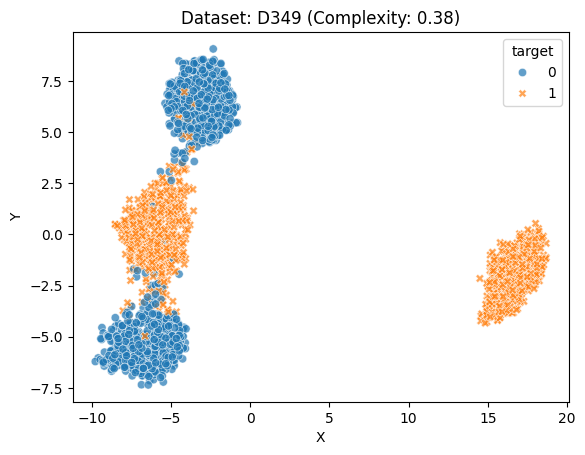

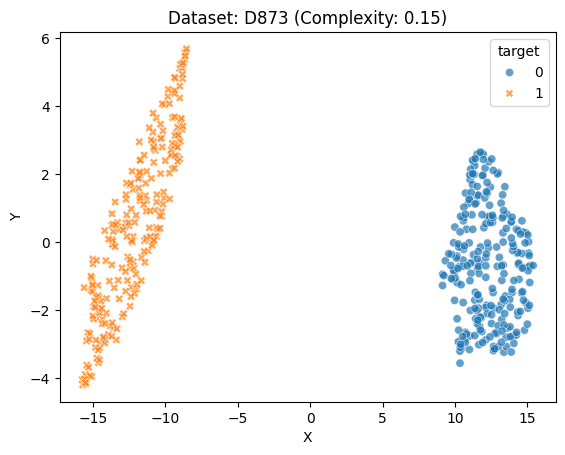

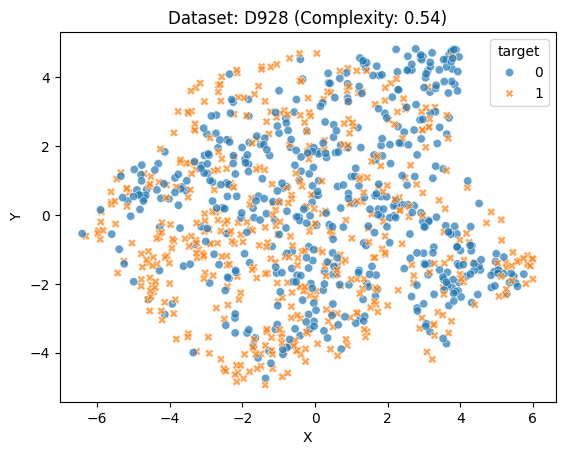

In [ ]:
PLOT = True

if PLOT:
  manifest = pd.read_csv(INPUT_DIR / f"{EXP}_manifest.csv")
  manifest

  try:
    import pacmap as pm

    sample_data = manifest[manifest["random_state"] == RANDOM_SEEDS[0]]
    sample_data = manifest[manifest["Dataset"].isin(SAMPLE_DATA.keys())]

    for row in sample_data.itertuples(index=False):
      df = pd.read_csv(project_path(row.full_path))
      X = df[get_feature_cols(df, target_col=TARGET_NAME)]
      y = df[TARGET_NAME]

      embedding = pm.PaCMAP(n_components=2, n_neighbors=10, MN_ratio=0.5, FP_ratio=2)
      X_transformed = pd.DataFrame(embedding.fit_transform(X, init="pca"), columns=["X", "Y"])

      plt.figure(row.Dataset)
      sns.scatterplot(data=X_transformed, x="X", y="Y", hue=y, style=y, alpha = 0.7).set_title("Dataset: " + row.Dataset + " (Complexity: " + str(SAMPLE_DATA[row.Dataset]) + ")")
      plt.savefig(FIG_DIR / f"pacmap_{row.Dataset}.png")
      plt.show()
  except ImportError:
    print("pacmap not installed; skipping PaCMAP plots")


**Fig. 2.** Visualization of selected example datasets with low (a), medium (b) and high (c) complexity, projected into 2-D using PaCMAP

In [60]:
SAMPLE_DATA_ID = SAMPLE_DATA_IDS[1]

sample_compl = sum_res_wide[["Dataset", "Synthesizer", "Repetition", "output_complex"]][(sum_res_wide["Dataset"] == SAMPLE_DATA_ID) & (sum_res_wide["Repetition"] == "R1")]
SAMPLE_COMPLEXITIES = pd.Series(sample_compl.output_complex.values.round(2),index=sample_compl.Synthesizer).to_dict()
SAMPLE_COMPLEXITIES = {SAMPLE_DATA_ID : SAMPLE_DATA[SAMPLE_DATA_ID]} | SAMPLE_COMPLEXITIES

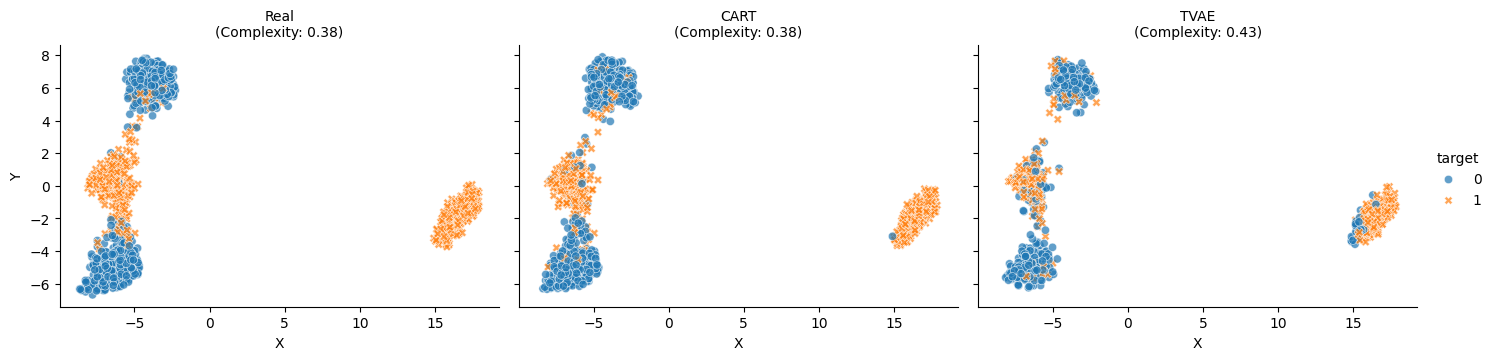

In [61]:
import pacmap as pm
sample_data = manifest[manifest["Dataset"].isin(SAMPLE_COMPLEXITIES.keys())]

for row in sample_data.itertuples(index=False):
    train_df = pd.read_csv(project_path(row.train_path))
    X_train = train_df[get_feature_cols(train_df, target_col=TARGET_NAME)]
    y_train = train_df[TARGET_NAME]

    embedding = pm.PaCMAP(
        n_components=2,
        n_neighbors=10,
        MN_ratio=0.5,
        FP_ratio=2,
        random_state=RANDOM_SEEDS[0],
    )
    embedding.fit(X_train, init="pca")

    transformed = pd.DataFrame(
        embedding.transform(X_train, basis=X_train),
        columns=["X", "Y"],
    )
    transformed["target"] = y_train
    transformed["Synthesizer"] = f"Real\n(Complexity: {SAMPLE_COMPLEXITIES[row.Dataset]})"

    plot_data = transformed.copy()
    model_col = "Model" if "Model" in synthetic_manifest.columns else "Synthesizer"

    for model_name in MODELS:
        mask = (
            (synthetic_manifest["Dataset"] == row.Dataset)
            & (synthetic_manifest["Repetition"] == "R1")
            & (synthetic_manifest[model_col] == model_name)
        )
        syn_path = synthetic_manifest.loc[mask, "synthetic_path"].iloc[0]
        syn_df = pd.read_csv(project_path(syn_path))
        X_syn = syn_df[get_feature_cols(syn_df, target_col=TARGET_NAME)]

        syn_transformed = pd.DataFrame(
            embedding.transform(X_syn, basis=X_train),
            columns=["X", "Y"],
        )
        syn_transformed["target"] = syn_df[TARGET_NAME]
        syn_transformed["Synthesizer"] = f"{model_name}\n(Complexity: {SAMPLE_COMPLEXITIES[model_name]})"
        plot_data = pd.concat([plot_data, syn_transformed], ignore_index=True)

    g = sns.FacetGrid(plot_data, col="Synthesizer", height=4, aspect=1.2)
    g.map_dataframe(sns.scatterplot, x="X", y="Y", hue="target", style="target", alpha=0.7)
    g.add_legend(title="target")
    g.fig.subplots_adjust(top=0.8)
    g.set_titles("{col_name}")
    if SAVE_FIGS:
        g.fig.savefig(FIG_DIR / f"pacmap_{row.Dataset}_syn.png")
    plt.show()

**Fig 3.** Visualization of generated samples obtained by TVAE and CART models for an example dataset with medium complexity, projected into 2-D using PaCMAP

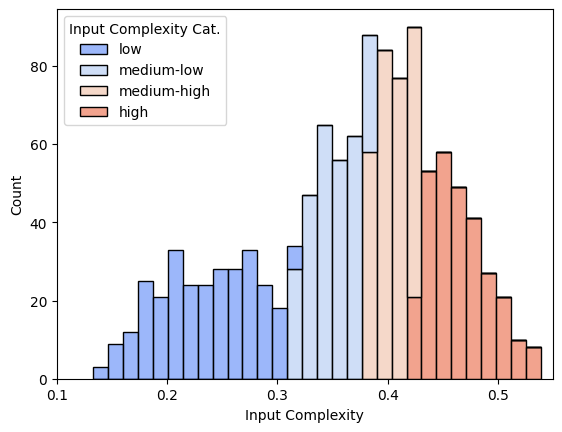

In [11]:
fig, ax = plt.subplots()
sns.histplot(
    input_data_wide,
    x="input_complex",
    hue="input_complex_cat",
    bins=30,
    multiple="stack",
    palette="coolwarm",
    ax=ax,
)
ax.set_xlim(0.1, 0.55)
ax.set_xlabel("Input Complexity")
ax.legend_.set_title("Input Complexity Cat.")
if SAVE_FIGS:
    fig.savefig(FIG_DIR / "input_complex_dist_4.png", bbox_inches="tight")

**Fig 4(a).** Distribution of aggregated complexity scores for input and output synthetic data. This overall score contemplates several dimensions of complexity, including feature-based, linearity, neighbourhood, network, dimensionality and class imbalance measures. Complexity values were discretized using quartiles.

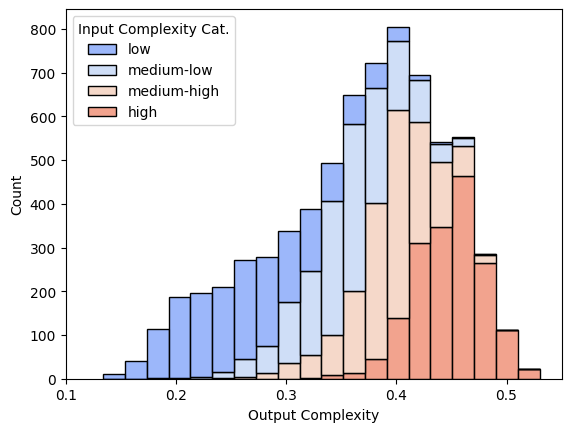

In [12]:
fig, ax = plt.subplots()
sns.histplot(
    sum_res_wide,
    x="output_complex",
    hue="input_complex_cat",
    bins=20,
    multiple="stack",
    palette="coolwarm",
    ax=ax,
)
ax.set_xlim(0.1, 0.55)
ax.set_xlabel("Output Complexity")
ax.legend_.set_title("Input Complexity Cat.")
if SAVE_FIGS:
    fig.savefig(FIG_DIR / "output_complex_dist.png", bbox_inches="tight")

**Fig 4(b).** Distribution of aggregated complexity scores for output synthetic data. This overall score contemplates several dimensions of complexity, including feature-based, linearity, neighbourhood, network, dimensionality and class imbalance measures. Complexity values were discretized using quartiles.

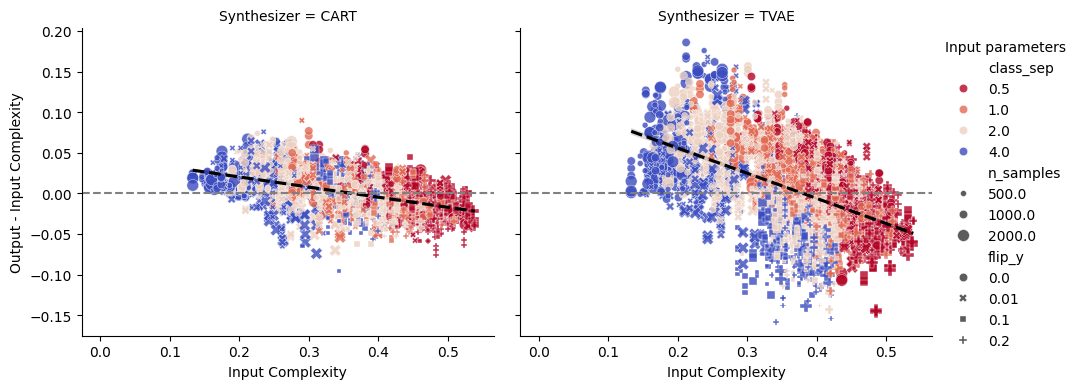

In [13]:
g = sns.FacetGrid(sum_res_wide, col="Synthesizer", height=4, aspect=1.2)
g.map_dataframe(
    sns.scatterplot,
    x="input_complex",
    y="complex_diff",
    hue="class_sep",
    style="flip_y",
    size="n_samples",
    alpha=0.8,
    palette="coolwarm_r",
)
g.map_dataframe(
    sns.regplot,
    x="input_complex",
    y="complex_diff",
    scatter=False,
    color="black",
    line_kws={"linestyle": "--"},
)
for ax in g.axes.flat:
    ax.axline((0, 0), slope=0, ls="--", color="grey")
g.add_legend(title="Input parameters")
g.set_axis_labels("Input Complexity", "Output - Input Complexity")
if SAVE_FIGS:
    g.fig.savefig(FIG_DIR / "input_output_complex_diff.png", bbox_inches="tight")
plt.show()

**Fig. 5.** Difference between output and input complexity scores against the input score for all synthetic datasets. Each point represents a synthetic data sample generated by a synthesizer; its color and shape reflect the parameters used to generate the original input data. Points above the dashed grey line indicate that the complexity of the synthetic data generated by the synthesizer exceed that of the input data used to train it. The dashed black line represents the linear trend.

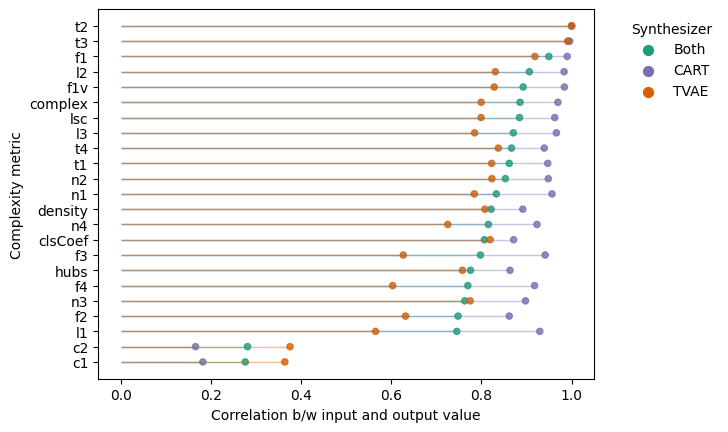

In [14]:
input_output_corr = []
for model in ["Both"] + MODELS:
    model_data = sum_res_wide if model == "Both" else sum_res_wide[sum_res_wide["Synthesizer"] == model]
    corr = model_data.corr(numeric_only=True)
    corr = corr[corr.index.str.startswith("input")].filter(regex="^output")
    corr = corr.set_index(corr.index.str.replace("input_", "", regex=False))
    corr.columns = corr.columns.str.replace("output_", "", regex=False)

    input_output_corr.append(
        pd.DataFrame({
            "Metric": corr.index,
            "Synthesizer": model,
            "Correlation": np.diag(corr),
        }).sort_values("Correlation")
    )
input_output_corr = pd.concat(input_output_corr, ignore_index=True)

palette = {
    "Both": "#1b9e77",
    "CART": "#7570b3",
    "TVAE": "#d95f02",
}
colors = input_output_corr["Synthesizer"].map(palette)

fig, ax = plt.subplots()
ax.hlines(
    y=input_output_corr["Metric"],
    xmin=0,
    xmax=input_output_corr["Correlation"],
    color=colors,
    alpha=0.4,
    linewidth=1,
)
ax.scatter(input_output_corr["Correlation"], input_output_corr["Metric"], c=colors, alpha=0.8, s=20)
ax.set_xlabel("Correlation b/w input and output value")
ax.set_ylabel("Complexity metric")
for model, color in palette.items():
    ax.scatter([], [], c=color, label=model, s=50)
ax.legend(title="Synthesizer", frameon=False, bbox_to_anchor=(1.05, 1), loc=0)
if SAVE_FIGS:
    fig.savefig(FIG_DIR / "input_output_complex_corr.png", bbox_inches="tight")

**Fig.6.** Correlations between individual input and output complexity meta-feature scores across all synthetic datasets, shown pooled and individually for each generator.

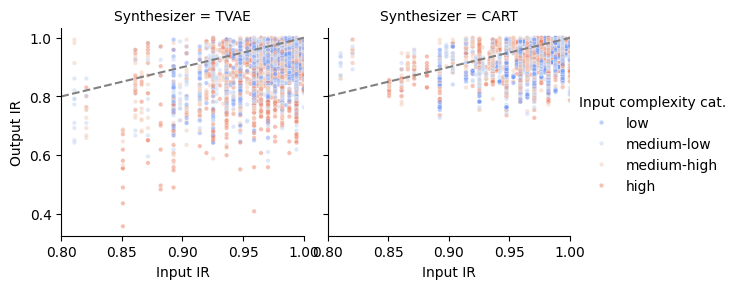

In [15]:
ir_plot_data = ratios.merge(
    input_data_wide[["Dataset", "input_complex", "input_complex_cat"]],
    on="Dataset",
)

g = sns.FacetGrid(ir_plot_data, col="Synthesizer")
g.map_dataframe(
    sns.scatterplot,
    x="Train_IR",
    y="Output_IR",
    hue="input_complex_cat",
    s=10,
    alpha=0.5,
    palette="coolwarm",
).add_legend(title="Input complexity cat.")
for ax in g.axes.flat:
    ax.axline((0.4, 0.4), slope=1, ls="--", color="grey")
g.set(xlim=(0.8, 1.0))
g.set_axis_labels("Input IR", "Output IR")
if SAVE_FIGS:
    g.fig.savefig(FIG_DIR / "input_output_ir.png", bbox_inches="tight")

**Fig. 7.** Relationship between input and synthetic imbalance ratios. Each point corresponds to a synthetic data sample generated by a synthesizer; its color represents the aggregate complexity score of the input data.  The x- and y-axes use different scales. The dashed grey line shows where points would fall if both ratios corresponded exactly to each other.

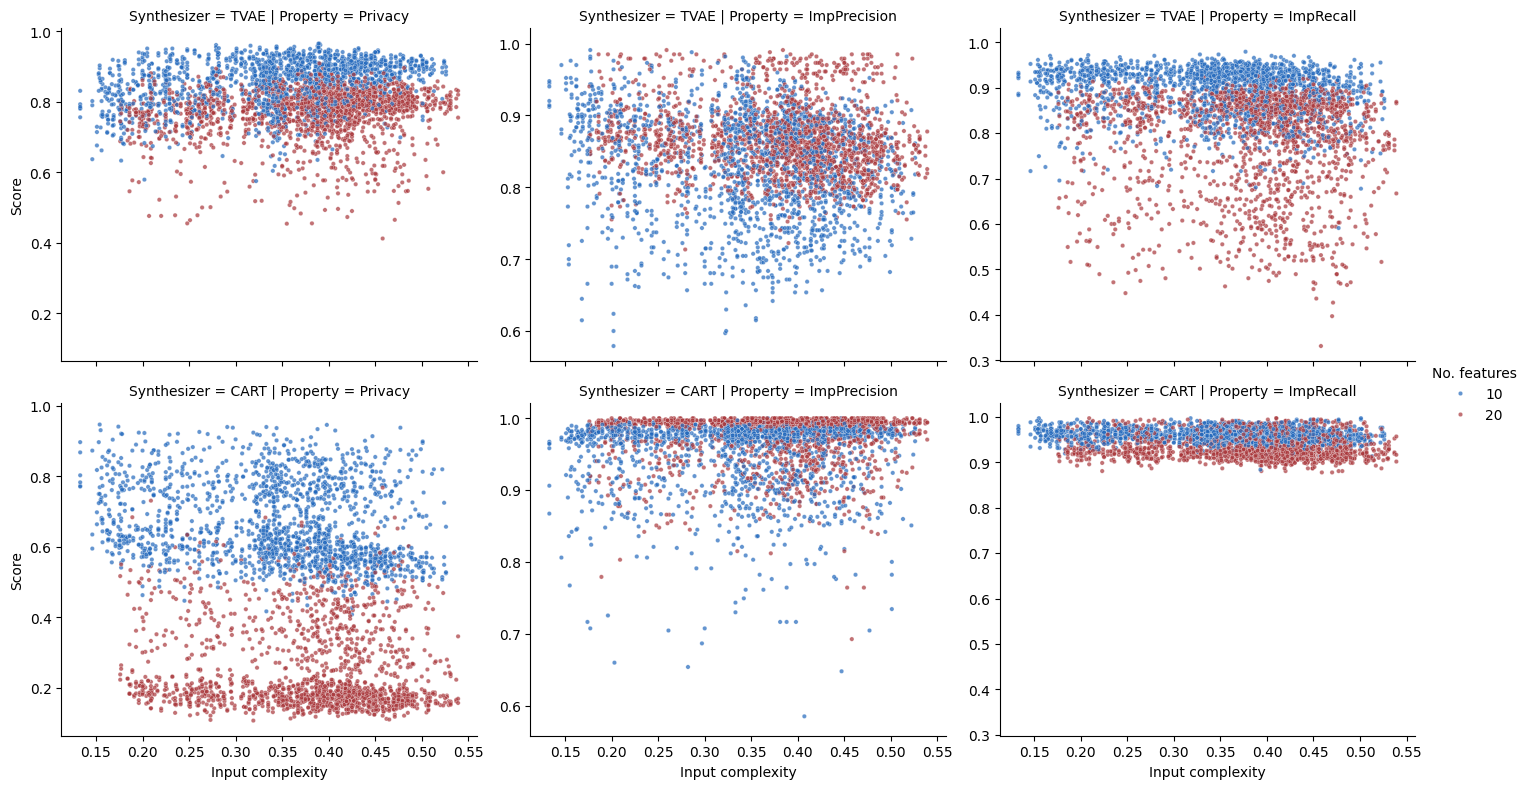

In [16]:
quality_scatter_data = sum_res_long[
    sum_res_long["EvalType"].isin(["sdv_qual", "pymdma"])
].merge(sum_res_wide, on=["Dataset", "Synthesizer", "Repetition"])
quality_scatter_data = quality_scatter_data[
    quality_scatter_data["Property"].isin(["ImpPrecision", "ImpRecall", "Privacy"])
]
quality_scatter_data["n_features"] = quality_scatter_data["n_features"].astype(int)

g = sns.FacetGrid(
    quality_scatter_data,
    row="Synthesizer",
    col="Property",
    aspect=1.2,
    height=4,
    sharey="col",
)
g.map_dataframe(
    sns.scatterplot,
    x="input_complex",
    y="Score",
    hue="n_features",
    alpha=0.7,
    palette="vlag",
    s=10,
).add_legend(title="No. features")
g.set_axis_labels("Input complexity", "Score")
if SAVE_FIGS:
    g.fig.savefig(FIG_DIR / "qual_complex_per_synth.png", bbox_inches="tight")

**Fig. 8.** Relationship between input complexity score and synthetic data quality metrics. One metric selected per quality dimension (improved precision, improved recall, and DCR privacy). Each point in the graph represents a synthetic data sample, and its colour denotes the number of features. Graphs for each metric share the same y-axis scale.

In [17]:
quality_box_data = sum_res_long.merge(
    input_data_wide[["Dataset", "input_complex_cat"]],
    on="Dataset",
)
quality_box_data = quality_box_data[
    ~quality_box_data["Property"].str.startswith("output_", na=False)
    & ~quality_box_data["Property"].isin(["Data Structure", "Data Validity"])
]

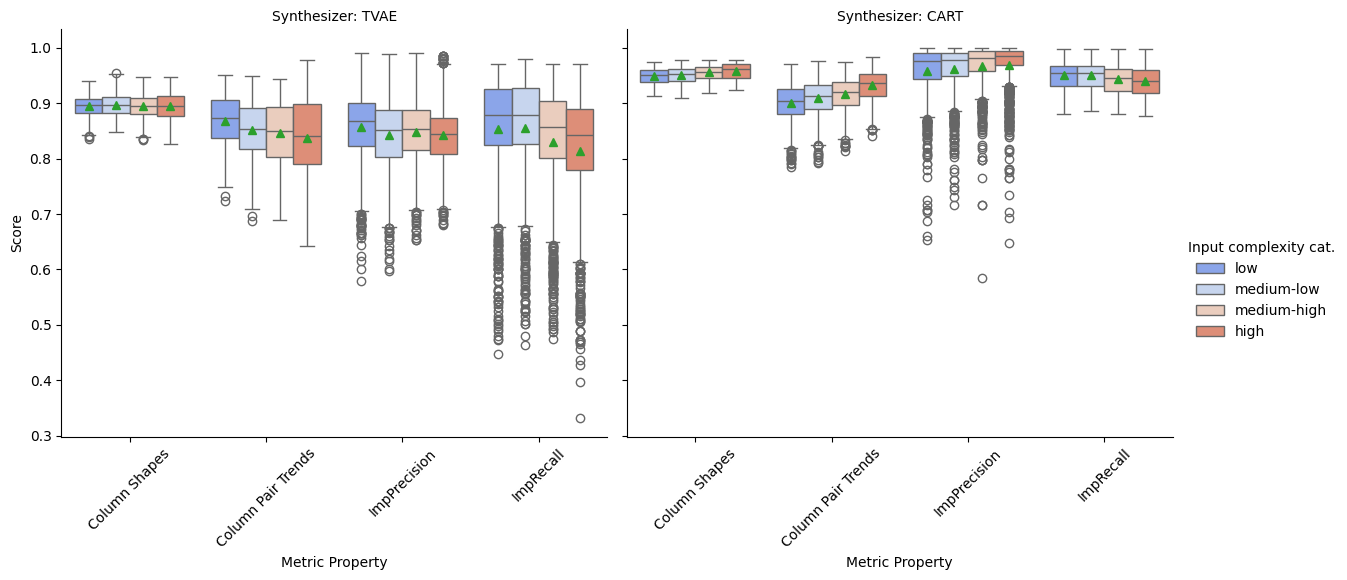

In [18]:
g = sns.FacetGrid(quality_box_data, col="Synthesizer", height=5, aspect=1.2)
g.map_dataframe(
    sns.boxplot,
    x="Property",
    y="Score",
    hue="input_complex_cat",
    palette="coolwarm",
    order=["Column Shapes", "Column Pair Trends", "ImpPrecision", "ImpRecall"],
    showmeans=True,
).add_legend(title="Input complexity cat.")
for ax in g.axes.flat:
    ax.tick_params(axis="x", labelrotation=45)
g.set_axis_labels("Metric Property", "Score")
g.set_titles("Synthesizer: {col_name}")
if SAVE_FIGS:
    g.fig.savefig(FIG_DIR / "avg_syn_data_quality_4cat_qual.png", bbox_inches="tight")
plt.show()

**Fig. 9(a).** Boxplots of synthetic data quality measures per input complexity category. The green triangles show the mean value of each metric, obtained by comparing the synthetic samples against the training data used to build the synthesizer. Input complexity values were discretized using quartiles.

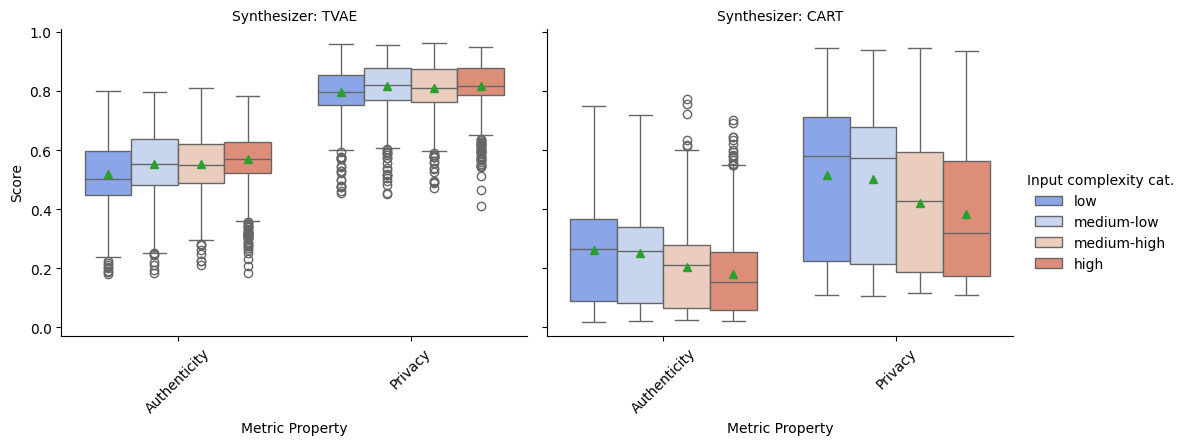

In [19]:
g = sns.FacetGrid(quality_box_data, col="Synthesizer", height=4, aspect=1.3)
g.map_dataframe(
    sns.boxplot,
    x="Property",
    y="Score",
    hue="input_complex_cat",
    palette="coolwarm",
    order=["Authenticity", "Privacy"],
    showmeans=True,
).add_legend(title="Input complexity cat.")
for ax in g.axes.flat:
    ax.tick_params(axis="x", labelrotation=45)
g.set_axis_labels("Metric Property", "Score")
g.set_titles("Synthesizer: {col_name}")
if SAVE_FIGS:
    g.fig.savefig(FIG_DIR / "avg_syn_data_quality_4cat_priv.png", bbox_inches="tight")
plt.show()

**Fig. 9(b).** Boxplots of synthetic data privacy measures per input complexity category. The green triangles show the mean value of each metric, obtained by comparing the synthetic samples against the training data used to build the synthesizer. Input complexity values were discretized using quartiles.

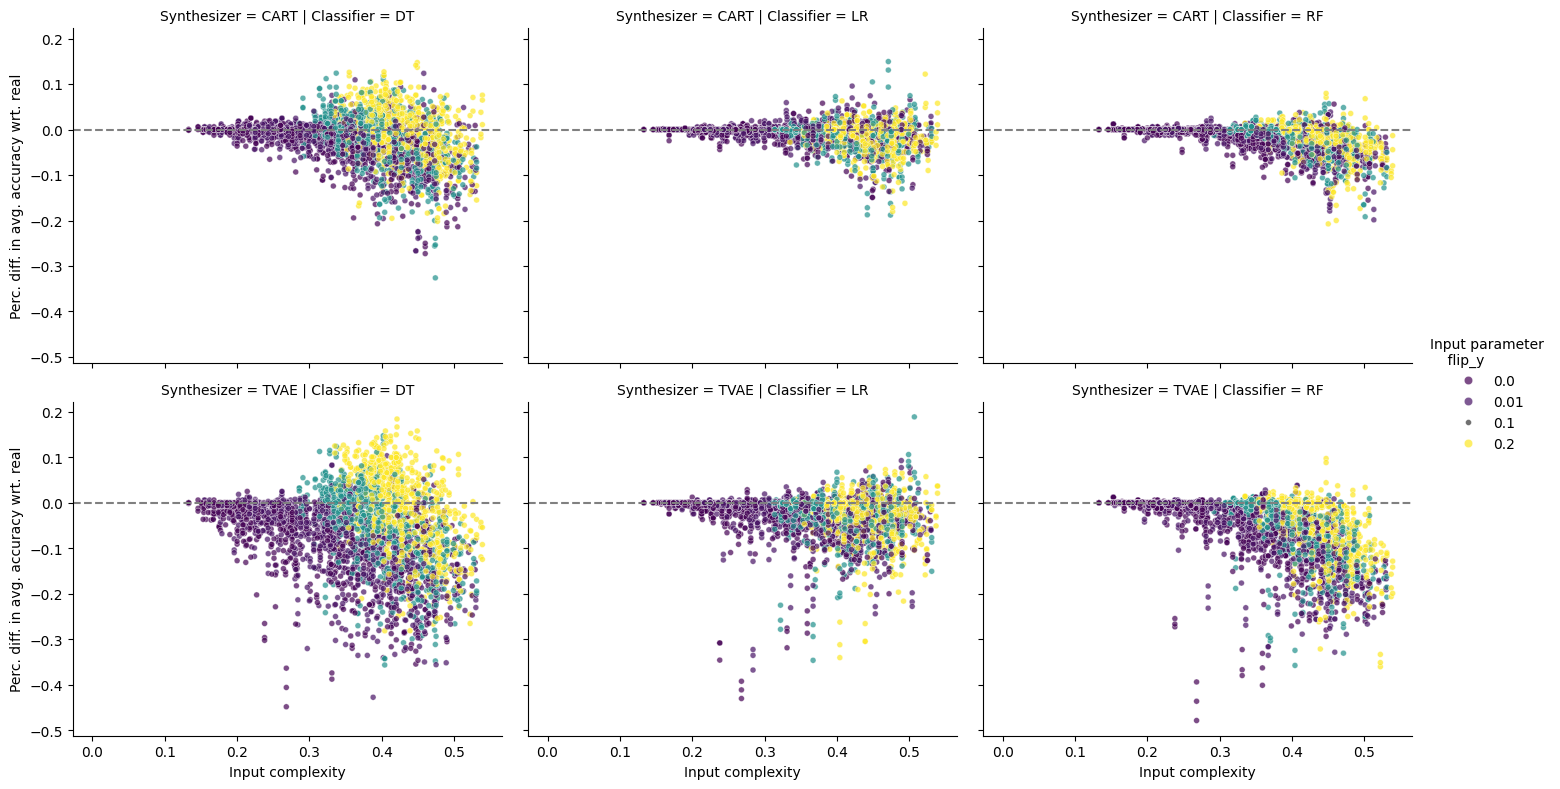

In [20]:
utility_scatter_data = utility_wide.merge(
    sum_res_wide[["Dataset", "Synthesizer", "Repetition", "output_complex"] + qual_metrics],
    on=["Dataset", "Synthesizer", "Repetition"],
    how="left",
)

g = sns.FacetGrid(utility_scatter_data, row="Synthesizer", col="Classifier", aspect=1.2, height=4)
g.map_dataframe(
    sns.scatterplot,
    x="input_complex",
    y="util_prop_diff_accuracy",
    hue="flip_y",
    alpha=0.7,
    palette="viridis",
    size=0.1,
).add_legend(title="Input parameter \n    flip_y")
for ax in g.axes.flat:
    ax.axline((0, 0), slope=0, ls="--", color="grey")
g.set_axis_labels("Input complexity", "Perc. diff. in avg. accuracy wrt. real")
if SAVE_FIGS:
    g.fig.savefig(FIG_DIR / "accuracy_utility_per_synth_clf.png", bbox_inches="tight")
plt.show()

**Fig. 10.** Relationship between input complexity score and synthetic data utility on a downstream classification task. Utility is measured as the difference between the accuracy of a classifier trained on the synthetic sample and that of a baseline classifier trained on the original training data. Each point in the graph represents a synthetic data sample and its colour denotes the level of label noise,  `flip\_y`, injected during input data generation. Points below the dashed line indicate a degradation in classification performance in the synthetic sample.

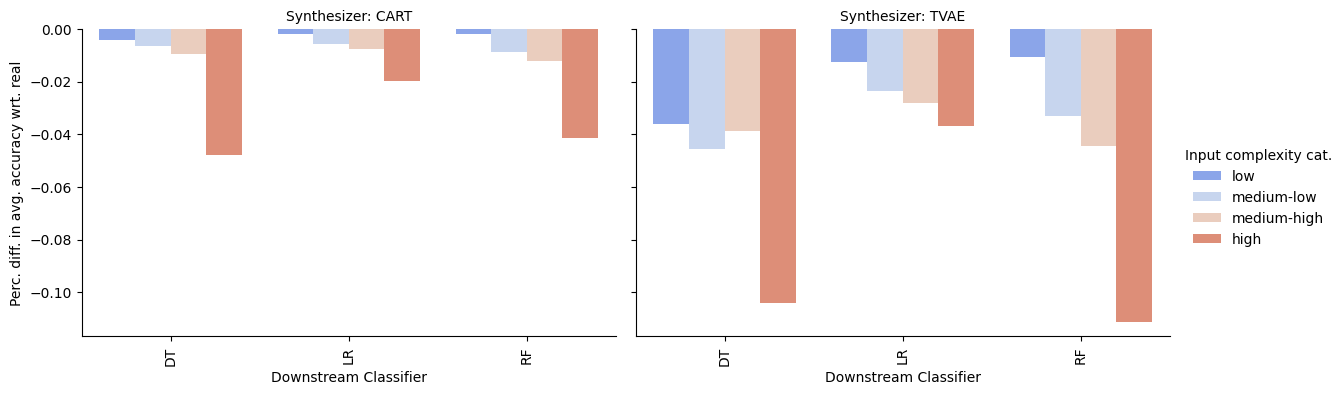

In [21]:
utility_bar_data = (
    utility_wide
    .groupby(["Synthesizer", "Classifier", "input_complex_cat"], observed=True)
    .mean(numeric_only=True)
    .reset_index()
)

g = sns.FacetGrid(utility_bar_data, col="Synthesizer", height=4, aspect=1.5)
g.map_dataframe(
    sns.barplot,
    x="Classifier",
    y="util_prop_diff_accuracy",
    hue="input_complex_cat",
    palette="coolwarm",
)
for ax in g.axes.flat:
    ax.tick_params(axis="x", labelrotation=90)
g.set_axis_labels("Downstream Classifier", "Perc. diff. in avg. accuracy wrt. real")
g.set_titles("Synthesizer: {col_name}")
g.add_legend(title="Input complexity cat.")
if SAVE_FIGS:
    g.fig.savefig(FIG_DIR / "avg_syn_utility_diff_4cat.png", bbox_inches="tight")
plt.show()

**Fig. 11.** Average synthetic data utility on a downstream classification task per input complexity category. Input complexity values were discretized using quartiles.

In [22]:
corr_source = sum_res_wide.merge(
    utility_wide_full,
    on=["Dataset", "Synthesizer", "Repetition"],
)
corr_source["Input complex."] = corr_source["input_complex"]
corr_source["Complex. diff."] = corr_source["complex_diff"]
corr_source["IR diff."] = (corr_source["Output_IR"] - corr_source["Train_IR"]).abs()

corr_data = corr_source[[
    "Synthesizer",
    "Input complex.",
    "Complex. diff.",
    "IR diff.",
    "Column Shapes",
    "Column Pair Trends",
    "ImpPrecision",
    "ImpRecall",
    "Authenticity",
    "Privacy",
    "Util diff. DT",
    "Util diff. RF",
    "Util diff. LR",
]]

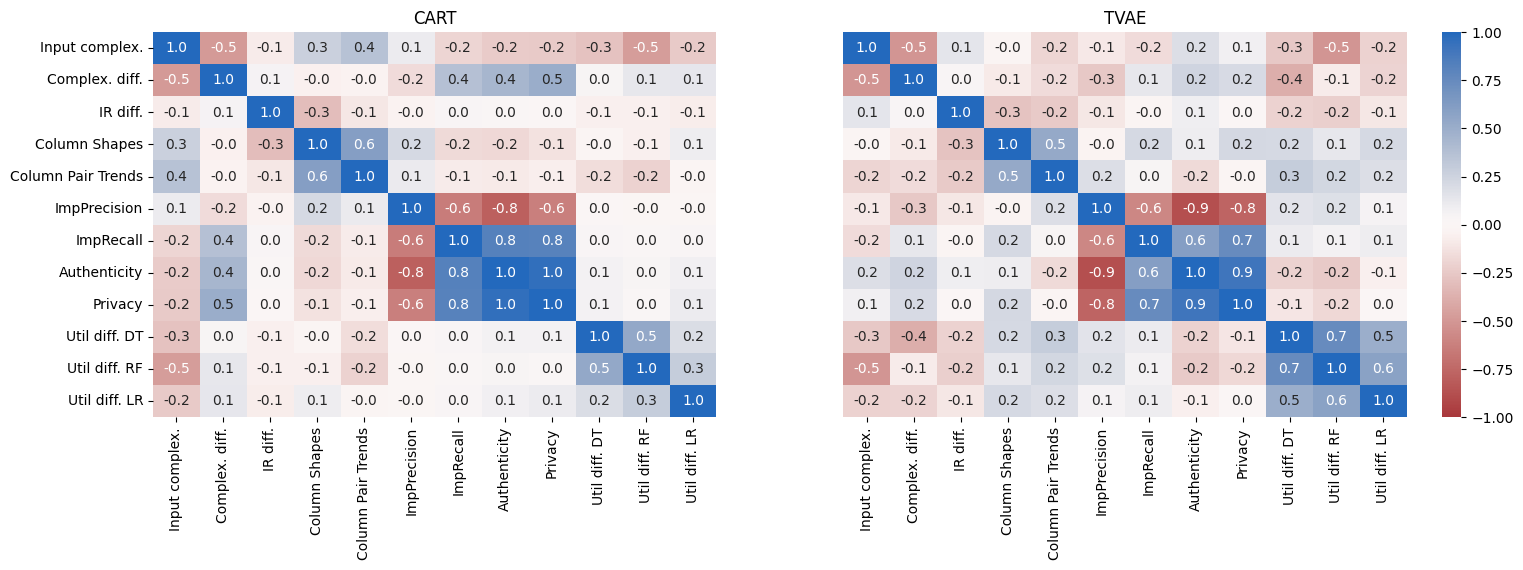

In [23]:
model_corrs = {}
fig, axs = plt.subplots(ncols=2, figsize=(18, 5), gridspec_kw={"width_ratios": [1, 1.25]})
for i, model in enumerate(MODELS):
    corr = corr_data[corr_data["Synthesizer"] == model].corr(numeric_only=True)
    model_corrs[model] = corr
    sns.heatmap(
        corr,
        cmap="vlag_r",
        annot=True,
        fmt=".1f",
        vmin=-1,
        vmax=1,
        cbar=model == "TVAE",
        ax=axs[i],
        yticklabels=model != "TVAE",
    )
    axs[i].set_title(model)
if SAVE_FIGS:
    fig.savefig(FIG_DIR / "complex_qual_corr_per_model.png", bbox_inches="tight")
plt.show()

**Fig. 12(a)** Correlation between input complexity score, difference in aggregate complexity score, difference in imbalance ratio, and synthetic data quality, privacy and utility metrics.

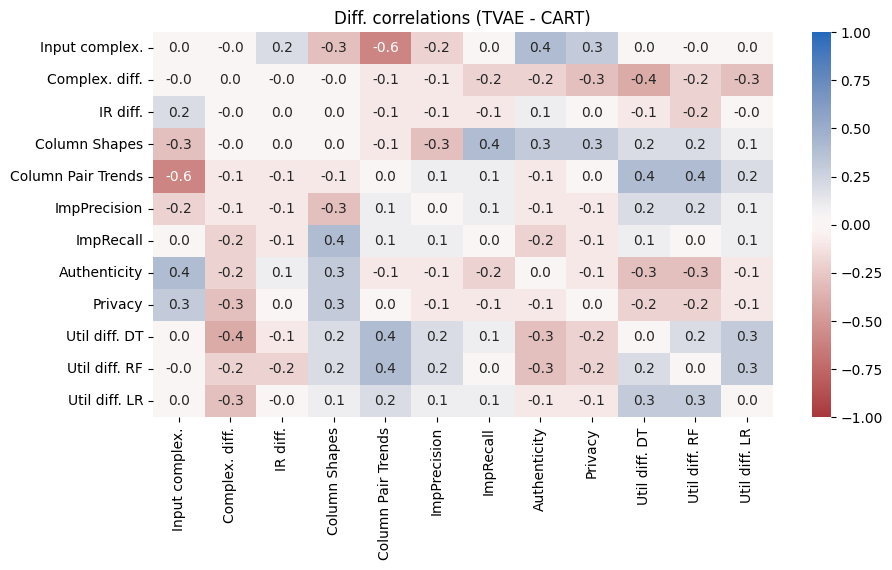

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    (model_corrs["TVAE"] - model_corrs["CART"]).round(1),
    cmap="vlag_r",
    annot=True,
    fmt=".1f",
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title("Diff. correlations (TVAE - CART)")
if SAVE_FIGS:
    fig.savefig(FIG_DIR / "complex_qual_corr_diff_models.png", bbox_inches="tight")
plt.show()

**Fig 12(b).**  Difference in correlation for the two synthesizers between input complexity score, difference in aggregate complexity score, difference in imbalance ratio, and synthetic data quality, privacy and utility metrics.